# LF 01 · Luminosity function of a TNG50 cluster-mass halo

Builds the r-band luminosity function of the most massive halo (halo 0) of the TNG50 simulation as a simulated comparison to A2199, and fits a Schechter function with MCMC (emcee).

**Inputs** (TNG50 catalogs are not included in the repository; see README)
- `DATA/TNG50/TNG50_output_snapNum_99/Massive_Haloinfo_SnapNum99.csv`, `.../snapNum_96/Massive_Haloinfo_SnapNum96.csv` – halo properties
- `DATA/TNG50/TNG50_output_snapNum_96/HALOCAT/halo00000000_result.csv` – subhalos of halo 0 at snapshot 96 (z ≈ 0.03), with absolute magnitudes

**Output**
- `TNG50_Halo0_LF.csv` – binned LF used by `06_multi_cluster_LF_comparison.ipynb`

Note: the volume normalisation adopts a cylinder of radius 30′ and depth 3 × radius at z = 0.03 (same as the A2199 volume), so only the shape of the LF is meaningful.

In [1]:
# ============================================================================
# Setup
# ============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import astropy.units as u
from astropy.cosmology import LambdaCDM

# Cosmology used throughout this project
cosmo = LambdaCDM(H0=70, Om0=0.3, Ode0=0.7)

# Matplotlib style shared by the notebooks of this repository
plt.rcParams.update({
    "font.family": 'STIXGeneral',
    'text.usetex': False,
    "mathtext.fontset": 'cm',
    "axes.labelweight": "normal",
    'font.size': 25,
    'font.weight': 'normal',

    # Ticks: inwards, on all four sides, with minor ticks
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'xtick.minor.visible': True,
    'ytick.minor.visible': True,
    'xtick.major.size': 10,
    'xtick.minor.size': 6,
    'ytick.major.size': 10,
    'ytick.minor.size': 6,
    'xtick.major.width': 1.6,
    'xtick.minor.width': 1.6,
    'ytick.major.width': 1.6,
    'ytick.minor.width': 1.6,

    # Axes and lines
    'lines.linewidth': 2,
    'axes.linewidth': 3.5,
    'axes.labelpad': 4,
    'xtick.major.pad': 7,
    'image.origin': 'lower'
})

# Show every column when a DataFrame is displayed
pd.set_option('display.max_columns', None)

## 0. Load the TNG50 halo catalogs

In [2]:
tng50_99_header = pd.read_csv('../../DATA/TNG50/TNG50_output_snapNum_99/Massive_Haloinfo_SnapNum99.csv')
tng50_96_header = pd.read_csv('../../DATA/TNG50/TNG50_output_snapNum_96/Massive_Haloinfo_SnapNum96.csv')

# TNG units: masses in 1e10 Msun/h, lengths in kpc/h
hparam = 0.6774

tng50_99_header['M200(solmass)'] = np.log10(tng50_99_header['Group_M_Crit200'] / hparam * 1e10)
tng50_96_header['M200(solmass)'] = np.log10(tng50_96_header['Group_M_Crit200'] / hparam * 1e10)

tng50_99_header['R200(Mpc)'] = tng50_99_header['Group_R_Crit200'] / hparam * 1e-3
tng50_96_header['R200(Mpc)'] = tng50_96_header['Group_R_Crit200'] / hparam * 1e-3

# Only halo 0 has an R200 comparable to A2199; its subhalo catalogs are used below
tng50_99_halo0 = pd.read_csv('../../DATA/TNG50/TNG50_output_snapNum_99/HALOCAT/halo00000000_result.csv')
tng50_96_halo0 = pd.read_csv('../../DATA/TNG50/TNG50_output_snapNum_96/HALOCAT/halo00000000_result.csv')

## 1. Extent of the halo

Size of the structure: distance between the reference subhalo (SubhaloIndex 7870) and the subhalo farthest from it. This cell also computes a comoving cylinder volume from that extent; the LF below uses the A2199-like cylinder instead (see the next section), so `volume_h3` is overwritten there.

In [3]:
from astropy.cosmology import Planck18 as cosmo    # TNG50 cosmology; replaces the project cosmology in this notebook

# 3-D positions of all subhalos of halo 0 (Mpc)
coords = tng50_96_halo0[['Distance_X (Mpc)', 'Distance_Y (Mpc)', 'Distance_Z (Mpc)']].values

# Reference subhalo
target_row = tng50_96_halo0[tng50_96_halo0['SubhaloIndex'] == 7870]
target_coord = target_row[['Distance_X (Mpc)', 'Distance_Y (Mpc)', 'Distance_Z (Mpc)']].values.squeeze()

# Distance from the reference subhalo to every other subhalo
diff = coords - target_coord
dists = np.linalg.norm(diff, axis=1)
dists[target_row.index[0]] = -np.inf          # ignore the reference itself

max_idx = np.argmax(dists)
max_distance = dists[max_idx]
farthest_row = tng50_96_halo0.iloc[max_idx]

print(f"Farthest subhalo from SubhaloIndex 7870: SubhaloIndex {farthest_row['SubhaloIndex']} at {max_distance:.3f} Mpc")

# Comoving cylinder volume from the extent of the halo (not used for the LF below)
L_phys = max_distance                                        # length of the structure (Mpc)
r_phys = np.mean(tng50_96_halo0['Distance (Mpc)']) * u.Mpc   # mean radial distance as the cylinder radius

z = 0.03
h = cosmo.H0.value / 100.0

scale_factor = 1 / (1 + z)
r_comoving = r_phys / scale_factor
L_comoving = L_phys / scale_factor

comoving_volume = np.pi * (r_comoving ** 2) * L_comoving
volume_h3 = comoving_volume.value * h**3      # h^-3 Mpc^3

Farthest subhalo from SubhaloIndex 7870: SubhaloIndex 65281 at 5.018 Mpc


## 2. Luminosity function and Schechter fit

Single Schechter function fitted with emcee (32 walkers, 5000 steps, first 1000 discarded). The LF is normalised by the comoving volume of a cylinder of radius 30′ and depth 3 × radius at z = 0.03, the same volume used for A2199. Errors on the counts are Poisson (√N).

  0%|          | 0/5000 [00:00<?, ?it/s]

  4%|▍         | 195/5000 [00:00<00:02, 1945.85it/s]

  8%|▊         | 391/5000 [00:00<00:02, 1949.44it/s]

 12%|█▏        | 590/5000 [00:00<00:02, 1963.86it/s]

 16%|█▌        | 787/5000 [00:00<00:02, 1961.68it/s]

...

 87%|████████▋ | 4329/5000 [00:02<00:00, 1934.87it/s]

 90%|█████████ | 4525/5000 [00:02<00:00, 1939.49it/s]

 94%|█████████▍| 4721/5000 [00:02<00:00, 1943.32it/s]

 98%|█████████▊| 4916/5000 [00:02<00:00, 1940.73it/s]

100%|██████████| 5000/5000 [00:02<00:00, 1950.15it/s]

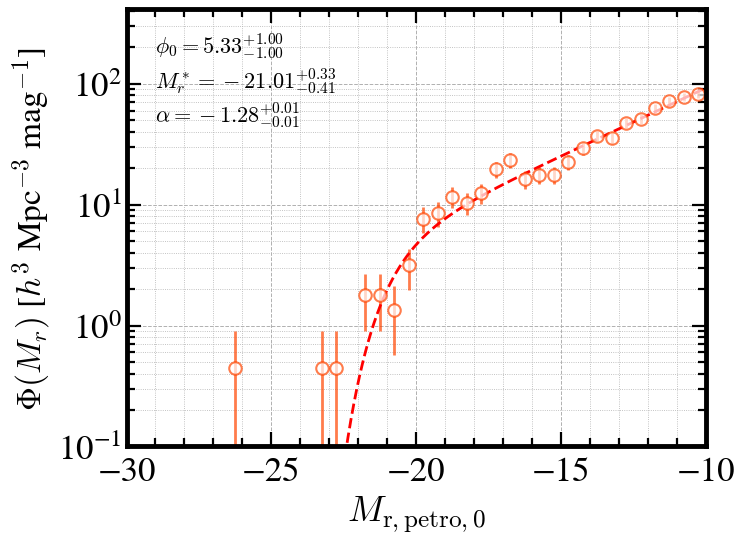

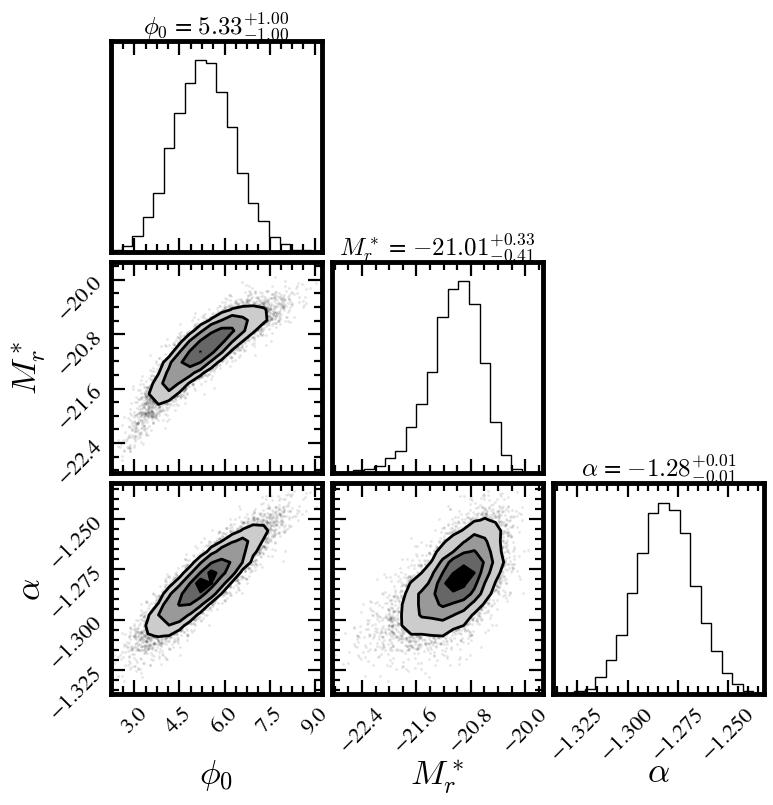

In [4]:
import emcee
import corner
from astropy.cosmology import Planck18 as cosmo

# ---- Schechter function in magnitudes and the log-posterior ----
def schechter_1D_LF(M, phi_0, M_star, alpha):
    exp_term = 10.0**(0.4 * (M_star - M))
    return phi_0 * exp_term**(1 + alpha) * np.exp(-exp_term)

def log_likelihood(theta, M, y, yerr):
    phi_0, M_star, alpha = theta
    model = schechter_1D_LF(M, phi_0, M_star, alpha)
    sigma2 = yerr**2
    return -0.5 * np.sum((y - model)**2 / sigma2 + np.log(2 * np.pi * sigma2))

def log_prior(theta):
    phi_0, M_star, alpha = theta
    if 0 < phi_0 < 100 and -30 < M_star < -10 and -3 < alpha < 0:     # flat priors
        return 0.0
    return -np.inf

def log_probability(theta, M, y, yerr):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, M, y, yerr)

# ---- Volume: cylinder of radius 30 arcmin and depth 3 x radius at z = 0.03 ----
h = cosmo.H0.value / 100.0
z = 0.03
com_dist = cosmo.comoving_distance(z)
theta_rad = (30 * u.arcmin).to(u.radian)
trans_dist = com_dist * theta_rad / u.radian
cyl_volume = 3 * np.pi * trans_dist**3
volume_h3 = cyl_volume.value * h**3

# ---- Binned LF (all subhalos with a magnitude, unit weights) ----
bin_width = 0.5
bin_edges = np.arange(-30, -10 + bin_width, bin_width)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

df_plot = tng50_96_halo0[tng50_96_halo0['Subhalo_AbsMag_r'] < 0].copy()
df_plot['weight'] = 1

weights = df_plot['weight'].values
hist, _ = np.histogram(df_plot['Subhalo_AbsMag_r'], bins=bin_edges, weights=weights)
variance, _ = np.histogram(df_plot['Subhalo_AbsMag_r'], bins=bin_edges, weights=weights**2)
yerr = np.sqrt(np.maximum(variance, 0))

hist_density = hist / (bin_width * volume_h3)
yerr_density = yerr / (bin_width * volume_h3)

fit_min, fit_max = -30, -10
fit_mask = (bin_centers > fit_min) & (bin_centers < fit_max) & (hist_density > 0)
x_fit = bin_centers[fit_mask]
y_fit = hist_density[fit_mask]
yerr_fit = yerr_density[fit_mask]

# ---- MCMC fit ----
init_params = np.array([10, -21.35, -1.24])       # phi_0, M*, alpha
nwalkers = 32
ndim = init_params.size
pos = init_params + 1e-4 * np.random.randn(nwalkers, ndim)

sampler = emcee.EnsembleSampler(nwalkers, ndim, log_probability, args=(x_fit, y_fit, yerr_fit))
sampler.run_mcmc(pos, 5000, progress=True)

samples = sampler.get_chain(discard=1000, thin=15, flat=True)

# Medians and 16-84 percentile errors
phi0_ci = np.percentile(samples[:, 0], [16, 50, 84])
mstar_ci = np.percentile(samples[:, 1], [16, 50, 84])
alpha_ci = np.percentile(samples[:, 2], [16, 50, 84])

phi0_err = [phi0_ci[1] - phi0_ci[0], phi0_ci[2] - phi0_ci[1]]
mstar_err = [mstar_ci[1] - mstar_ci[0], mstar_ci[2] - mstar_ci[1]]
alpha_err = [alpha_ci[1] - alpha_ci[0], alpha_ci[2] - alpha_ci[1]]

phi0_med, mstar_med, alpha_med = phi0_ci[1], mstar_ci[1], alpha_ci[1]

# ---- LF with the best-fit Schechter function ----
fig, ax = plt.subplots(figsize=(8, 6))

ax.axvspan(-30, fit_min, color='gray', alpha=0.7)
ax.axvspan(fit_max, -10, color='gray', alpha=0.7)

mask_pos = hist_density > 0
ax.errorbar(bin_centers[mask_pos], hist_density[mask_pos], yerr=yerr_density[mask_pos],
            fmt='o', color='orangered', ecolor='orangered', markerfacecolor='white',
            markeredgewidth=1.5, capsize=0, alpha=0.7, markersize=9)

x_model = np.linspace(-30, -10, 1000)
ax.plot(x_model, schechter_1D_LF(x_model, phi0_med, mstar_med, alpha_med),
        color='red', linestyle='--', lw=2.0)

ax.set_yscale('log')
ax.set_xlim(-30, -10)
ax.set_ylim([1e-1, hist_density.max() * 5])
ax.set_xlabel(r'$M_\mathrm{r,petro,0}$', fontsize=26)
ax.set_ylabel(r'$\Phi(M_r)$ [$h^3$ Mpc$^{-3}$ mag$^{-1}$]', fontsize=24)
ax.grid(True, which='major', linestyle='--', linewidth=0.7)
ax.grid(True, which='minor', linestyle=':', linewidth=0.6)
ax.minorticks_on()
ax.tick_params(axis='both', which='both', direction='in', top=True, right=True)

ann = (
    r"$\phi_0 = {:.2f}^{{+{:.2f}}}_{{-{:.2f}}}$".format(phi0_med, phi0_err[1], phi0_err[0]) + '\n' +
    r"$M^*_r = {:.2f}^{{+{:.2f}}}_{{-{:.2f}}}$".format(mstar_med, mstar_err[1], mstar_err[0]) + '\n' +
    r"$\alpha = {:.2f}^{{+{:.2f}}}_{{-{:.2f}}}$".format(alpha_med, alpha_err[1], alpha_err[0])
)
ax.text(0.05, 0.95, ann, transform=ax.transAxes, fontsize=16,
        verticalalignment='top', horizontalalignment='left',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='none', edgecolor='none', alpha=0.8))

plt.tight_layout()
plt.show()

# ---- Posterior corner plot ----
labels = [r"$\phi_0$", r"$M^*_r$", r"$\alpha$"]
fig = corner.corner(samples, labels=labels,
                    show_titles=True,
                    title_fmt='.2f',
                    title_kwargs={"fontsize": 18},
                    plot_contours=True,
                    fill_contours=True,
                    fig=plt.figure(figsize=(8, 8))
)
for ax in fig.get_axes():
    ax.tick_params(axis='both', labelsize=16)
plt.show()

# ---- Save the binned LF for the multi-cluster comparison ----
df_fit = pd.DataFrame({'M_r': x_fit, 'Phi': y_fit, 'Phi_err': yerr_fit})
df_fit.to_csv('TNG50_Halo0_LF.csv', index=False)